In [61]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import csv
import argparse
import os

# Исходный код (из дополнения)

In [62]:
def generate_time_series(n_points=1000, has_trend=True, has_seasonality=True, seed=None):
    """
    Генерирует временной ряд со случайными параметрами без использования
    Pandas
    Параметры:
    ----------
    n_points : int
    Количество точек данных
    has_trend : bool
    Добавлять ли тренд
    has_seasonality : bool
    Добавлять ли сезонность
    seed : int или None
    Seed для воспроизводимости
    Возвращает:
    -----------
    tuple: (dates, values) где dates - список строк дат, values - список
    значений
    """
    
    if seed is not None:
        np.random.seed(seed)
    
    # Генерируем временные метки (ежедневные данные начиная с 2020-01-01)
    start_date = datetime(2020, 1, 1)
    dates = [(start_date + timedelta(days=i)).strftime('%Y-%m-%d') for i in range(n_points)]
    
    # Базовый шум (случайная компонента)
    noise = np.random.normal(0, 5, n_points)
    
    # Инициализируем компоненты
    trend_component = np.zeros(n_points)
    seasonal_component = np.zeros(n_points)
    
    # Генерируем тренд, если требуется
    if has_trend:
        # Случайно выбираем тип тренда: линейный, квадратичный или логарифмический
        trend_type = np.random.choice(['linear', 'quadratic', 'logarithmic'])
    
    if trend_type == 'linear':
        # Линейный тренд: y = mx + b
        slope = np.random.uniform(-0.5, 0.5) # случайный наклон
        intercept = np.random.uniform(50, 100) # случайное начальное значение
        trend_component = slope * np.arange(n_points) + intercept
    elif trend_type == 'quadratic':
        # Квадратичный тренд: y = ax^2 + bx + c
        a = np.random.uniform(-0.001, 0.001)
        b = np.random.uniform(-0.1, 0.1)
        c = np.random.uniform(50, 100)
        x = np.arange(n_points)
        trend_component = a * x**2 + b * x + c
    else: # logarithmic
        # Логарифмический тренд: y = a*log(x+1) + b
        a = np.random.uniform(10, 30)
        b = np.random.uniform(50, 100)
        trend_component = a * np.log(np.arange(n_points) + 1) + b
    
    # Генерируем сезонность, если требуется
    if has_seasonality:
        # Случайное количество сезонных компонент (1-3)
        n_seasons = np.random.randint(1, 4)
        for _ in range(n_seasons):
            # Случайные параметры для каждой сезонной компоненты
            amplitude = np.random.uniform(10, 30) # амплитуда
            period = np.random.uniform(30, 365) # период в днях
            phase = np.random.uniform(0, 2*np.pi) # фаза
            # Создаем сезонную компоненту (синусоида)
            seasonal_component += amplitude * np.sin(2*np.pi*np.arange(n_points)/period + phase)
    # Комбинируем все компоненты
    values = noise + trend_component + seasonal_component
    return dates, values

def save_to_csv(dates, values, filename=None):
    """
    Сохраняет временной ряд в CSV файл без использования Pandas
    Параметры:
    ----------
    dates : list
    Список дат в строковом формате
    values : list или np.array
    Список значений временного ряда
    filename : str или None
    Имя файла. Если None, генерируется автоматически
    """

    if filename is None:
        # Генерируем имя файла с текущей датой и временем
        current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        filename = f"tsdata_{current_time}.csv"

    # Сохраняем в CSV
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        # Записываем заголовок
        writer.writerow(['date', 'value'])
        # Записываем данные
        for date, value in zip(dates, values):
            writer.writerow([date, f"{value:.6f}"])
    
    print(f"Данные сохранены в файл: {filename}")
    print(f"Размер данных: {len(dates)} строк")
    return filename

def plot_time_series(dates, values, figsize=(14, 6)):
    """
    Визуализирует временной ряд без использования Pandas
    Параметры:
    ----------
    dates : list
    Список дат в строковом формате
    values : list или np.array
    Список значений временного ряда
    figsize : tuple
    Размер фигуры
    """
    # Преобразуем строки дат в объекты datetime для matplotlib
    date_objects = [datetime.strptime(date_str, '%Y-%m-%d') for date_str in dates]
    
    plt.figure(figsize=figsize)
    
    # Строим график временного ряда
    plt.plot(date_objects, values, label='Временной ряд', color='blue', linewidth=1.5)
    plt.title('Сгенерированный временной ряд', fontsize=16, fontweight='bold')
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Автоматически форматируем ось X для дат
    plt.gcf().autofmt_xdate()
    
    # Добавляем информацию о данных
    values_array = np.array(values)
    stats_text = f"Всего точек: {len(values)}\nСреднее:{np.mean(values_array):.2f}\nСтандартное отклонение:{np.std(values_array):.2f}"
    plt.figtext(0.02, 0.02, stats_text, fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))
    plt.tight_layout()
    plt.show()

def generate_statistics(values):
    """Генерирует статистику по данным"""
    values_array = np.array(values)
    
    return {
    'count': len(values_array),
    'mean': np.mean(values_array),
    'std': np.std(values_array),
    'min': np.min(values_array),
    'max': np.max(values_array),
    '25%': np.percentile(values_array, 25),
    '50%': np.percentile(values_array, 50),
    '75%': np.percentile(values_array, 75)
    }

1. С помощью приложенного файла сгенерировать временной ряд. Отрисовать ряд

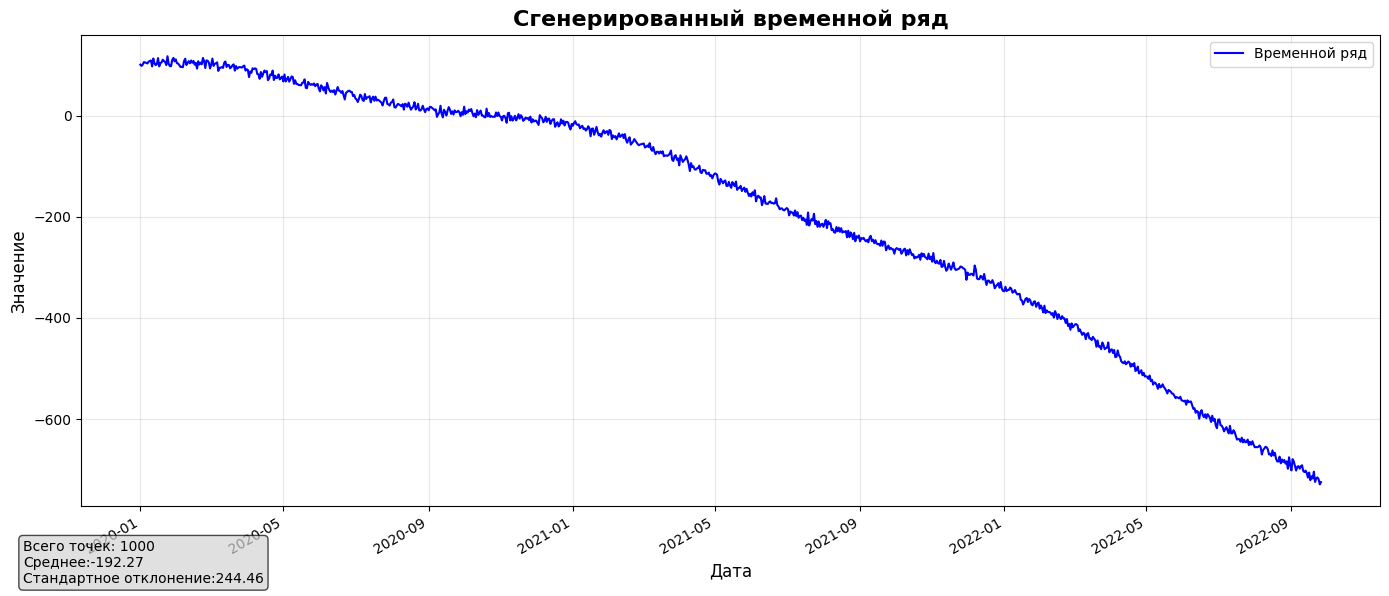

In [63]:
dates, values =  generate_time_series()
plot_time_series(dates, values)

2. Провести классические статистические тесты

In [64]:
from statsmodels.tsa.stattools import adfuller, kpss

values = np.array(values)

adf_stat, adf_p_value, *_ = adfuller(values)
print("ADF:")
print(f"Statistic\t=\t{adf_stat:.3f}")
print(f"P-value\t\t=\t{adf_p_value:.3f}")

kpss_stat, kpss_p_value, *_ = kpss(values)
print("KPSS:")
print(f"Statistic\t=\t{kpss_stat:.3f}")
print(f"P-value\t\t=\t{kpss_p_value:.3f}")

ADF:
Statistic	=	9.033
P-value		=	1.000
KPSS:
Statistic	=	4.873
P-value		=	0.010


C:\Users\Nick\AppData\Local\Temp\ipykernel_12916\241932915.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p_value, *_ = kpss(values)


3. Провести разделение ряда на компоненты

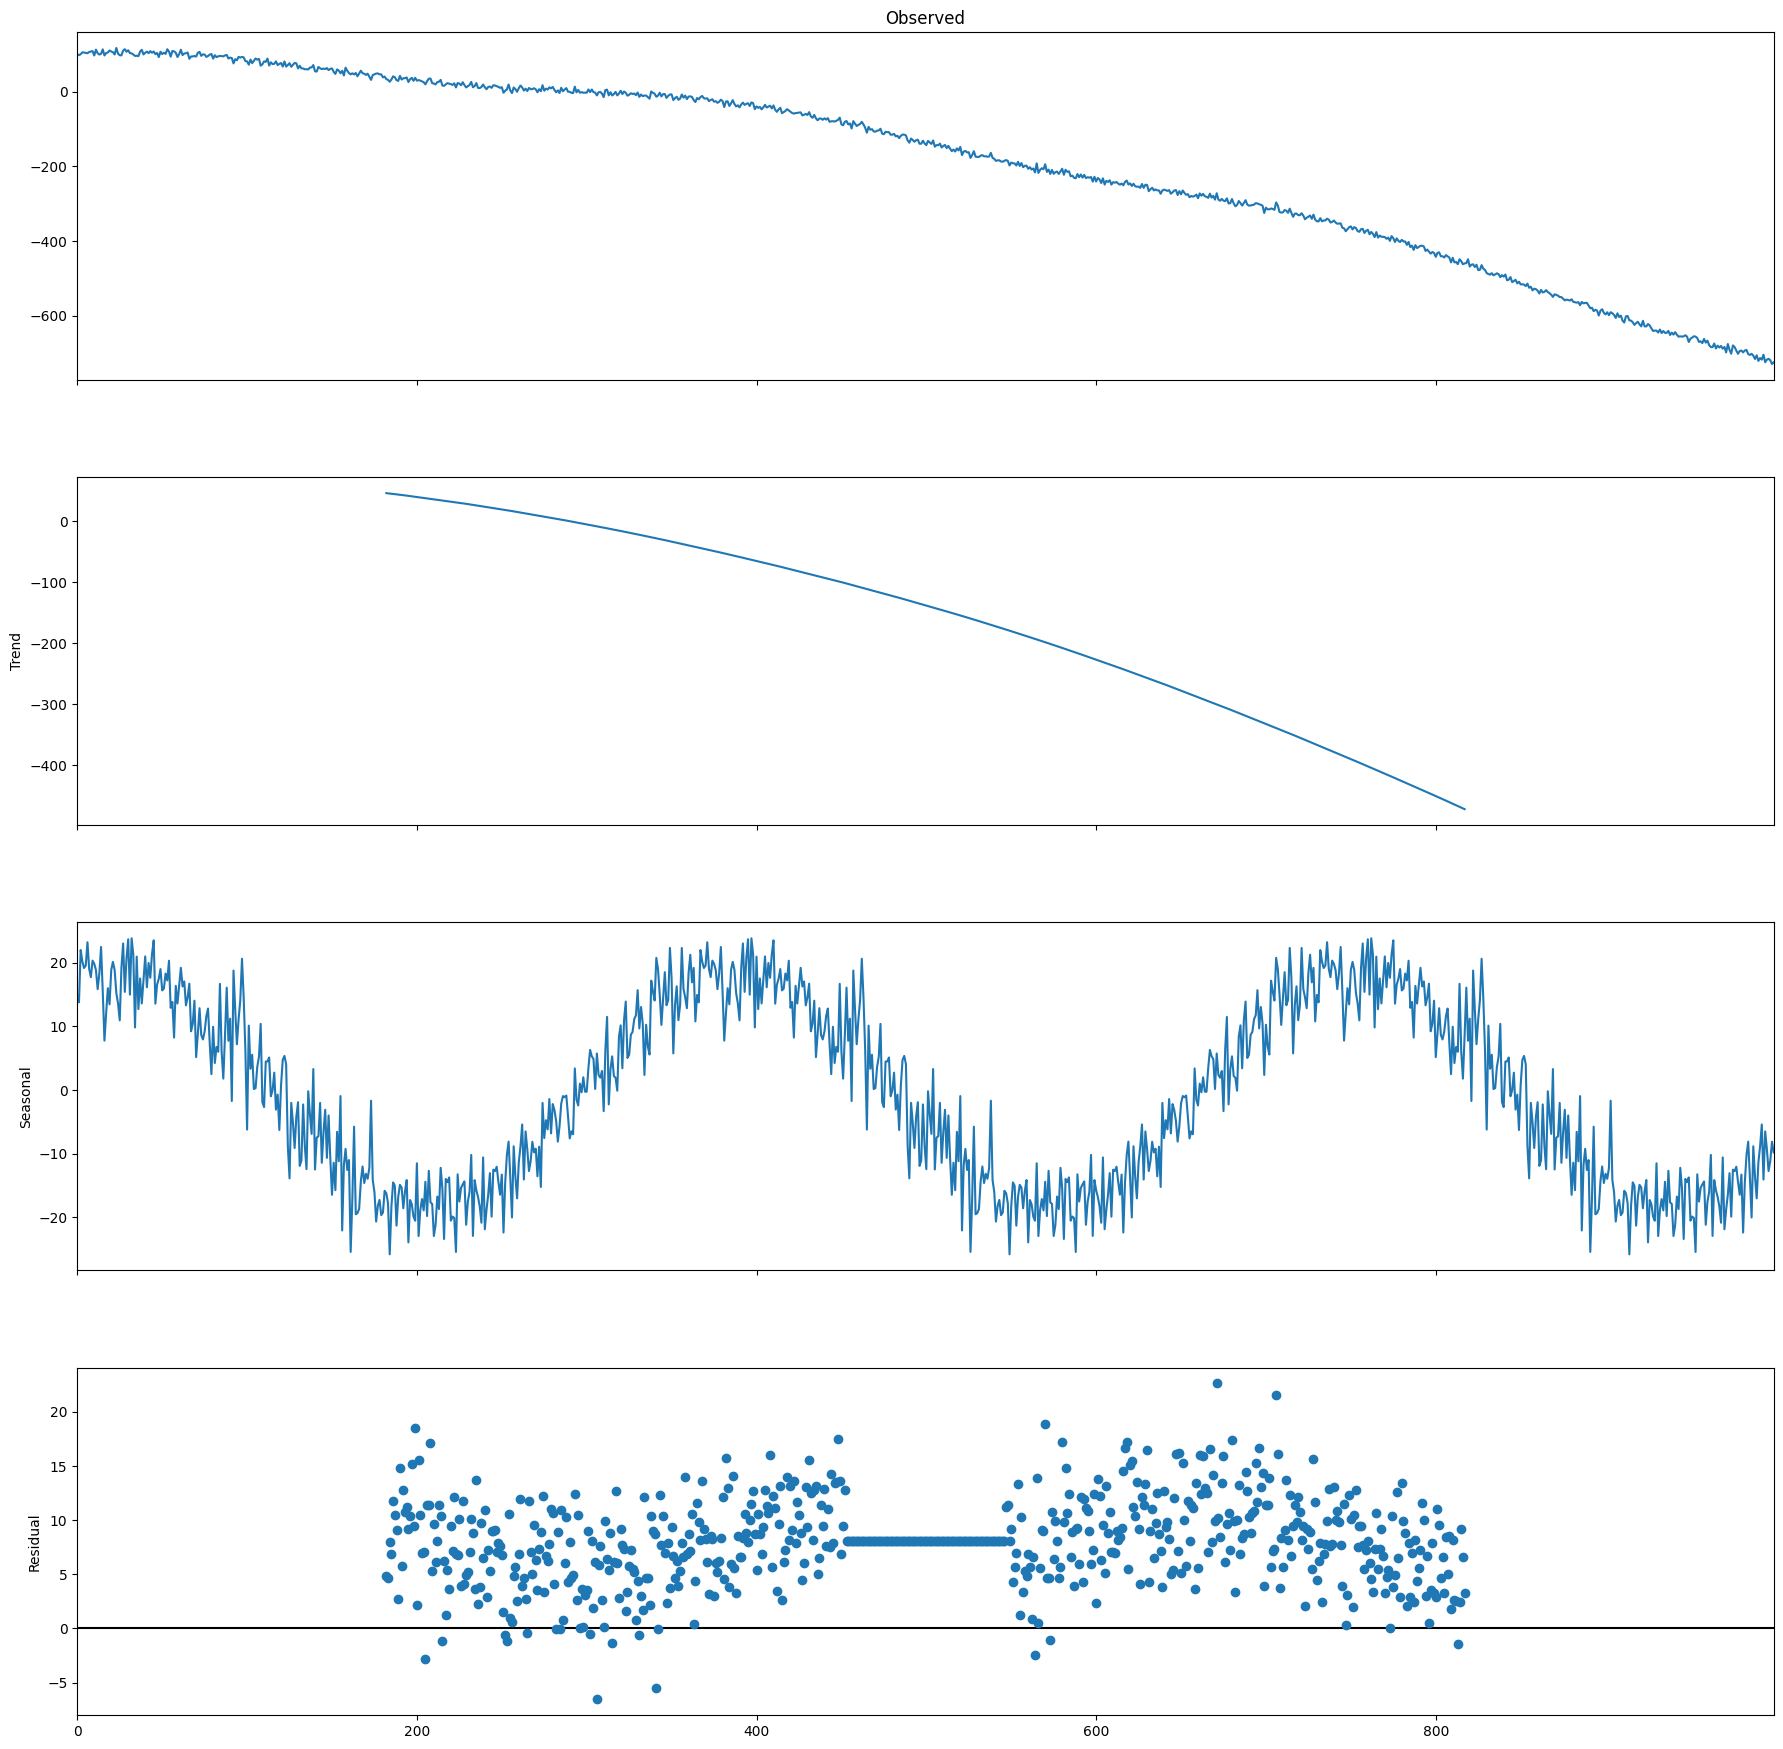

In [65]:
from statsmodels.tsa.seasonal import seasonal_decompose

seasonal_decompose(values, period=365).plot().set_size_inches(20,20)

4. Отрисовать автокорреляционные функции

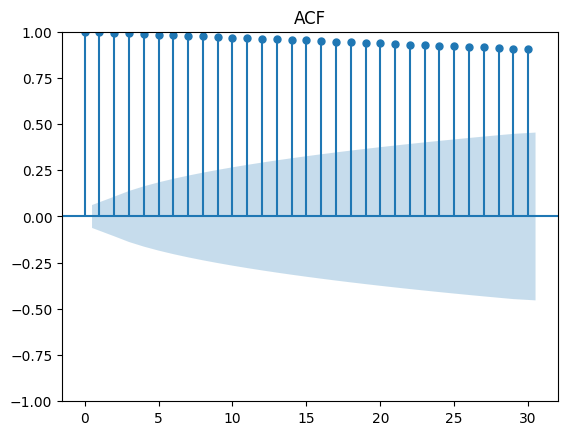

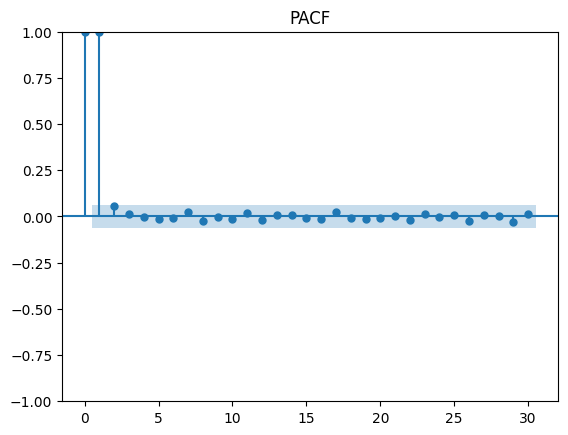

In [66]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(values, lags=30)
plt.title("ACF")
plt.show()

plot_pacf(values, lags=30)
plt.title("PACF")
plt.show()

5. Выбрать статистический метод моделирования. Привести текстовое обоснование выбора. Смоделировать ряд, сделав предсказание на разумный период

Взята модель SARIMA, поскольку среди данных есть тренд и сезонность, а SARIMA как раз отлично подходит для этого

In [67]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_size = round(len(values) * 0.9)
train = values[:train_size]
test = values[train_size:]

model = SARIMAX(train, order=(1,1,1), seasonal_order=(4,0,3,12))

result = model.fit()
result.summary()

C:\Users\Nick\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                         SARIMAX Results                                          
==================================================================================================
Dep. Variable:                                          y   No. Observations:                  900
Model:             SARIMAX(1, 1, 1)x(4, 0, [1, 2, 3], 12)   Log Likelihood               -2875.774
Date:                                    Sun, 21 Dec 2025   AIC                           5771.547
Time:                                            16:39:09   BIC                           5819.560
Sample:                                                 0   HQIC                          5789.890
                                                    - 900                                         
Covariance Type:                                      opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0241      0.043     -0.564      0.573      -0.108       0.060
ma.L1         -0.7715      0.031    -24.967      0.000      -0.832      -0.711
ar.S.L12       0.4408      0.455      0.970      0.332      -0.450       1.332
ar.S.L24       0.0598      0.406      0.147      0.883      -0.735       0.855
ar.S.L36       0.4254      0.417      1.021      0.307      -0.392       1.242
ar.S.L48       0.0525      0.049      1.076      0.282      -0.043       0.148
ma.S.L12      -0.3398      0.453     -0.750      0.453      -1.228       0.549
ma.S.L24       0.0004      0.374      0.001      0.999      -0.733       0.734
ma.S.L36      -0.4351      0.366     -1.190      0.234      -1.152       0.282
sigma2        34.6327      1.625     21.317      0.000      31.448      37.817
===================================================================================
Ljung-Box (L1) (Q):                   0.86   Jarque-Bera (JB):                 0.78
Prob(Q):                              0.35   Prob(JB):                         0.68
Heteroskedasticity (H):               0.95   Skew:                             0.01
Prob(H) (two-sided):                  0.67   Kurtosis:                         3.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

6. Провести анализ метрик

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

start = len(train)
end = len(train) + len(test) - 1

pred = result.predict(start=start, end=end)

mae = mean_absolute_error(test, pred)
mse = mean_squared_error(test, pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, pred)
r2 = r2_score(test, pred)

print(f"MAE\t=\t{mae}")
print(f"MSE\t=\t{mse}")
print(f"RMSE\t=\t{rmse}")
print(f"MAPE\t=\t{mape}")
print(f"R2\t=\t{r2}")

MAE	=	7.545972316923788
MSE	=	81.07749514495363
RMSE	=	9.004304256573832
MAPE	=	0.011310590264379958
R2	=	0.9436453370990365


Имеем хорошие результаты. R2=0.94 указывает, что модель эффективно объясняет большую часть вариации временного ряда. Несмотря на высокие значения MAE и RSE, MAPE остаётся низкой, что говорит о высокой точности прогнозов в процентном соотношении.  

7. Изобразить график модели с предсказанием с учетом возможных ошибок

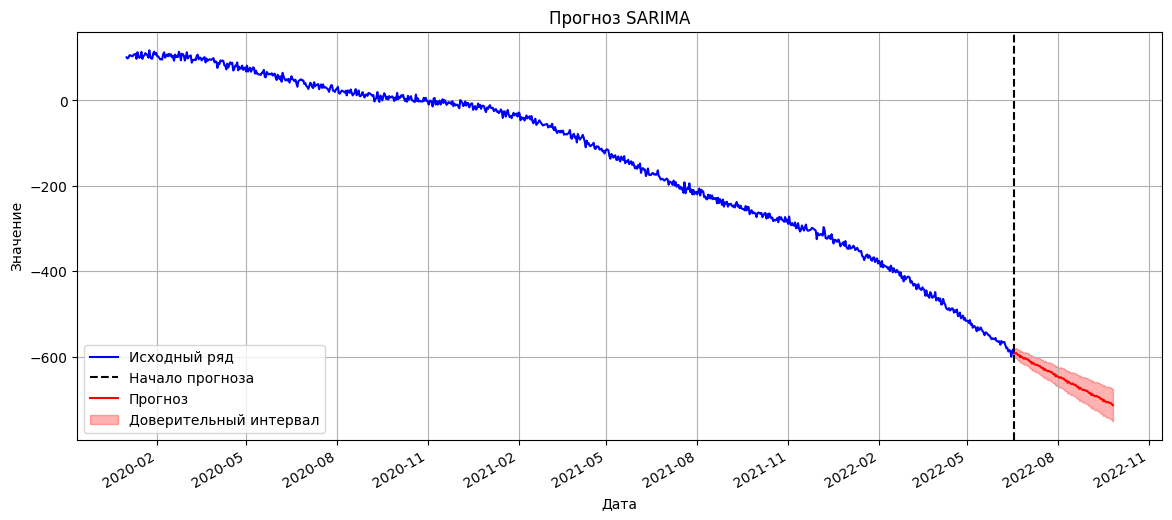

In [69]:
import matplotlib.dates as mdates

forecast = result.get_forecast(steps=len(test))
pred = forecast.predicted_mean
conf_int = forecast.conf_int()  

train_dates = [datetime.strptime(d, '%Y-%m-%d') for d in dates[:train_size]]
test_dates = [datetime.strptime(d, '%Y-%m-%d') for d in dates[train_size:]]

plt.figure(figsize=(14, 6))
plt.plot(train_dates, values[:train_size], label="Исходный ряд", color="blue")
plt.axvline(train_dates[-1], color="black", linestyle="--", label="Начало прогноза")
plt.plot(test_dates, pred, color="red", label="Прогноз")
plt.fill_between(test_dates, conf_int[:, 0], conf_int[:, 1], color="red", alpha=0.3, label="Доверительный интервал")

plt.legend()
plt.grid(True)
plt.title("Прогноз SARIMA")
plt.xlabel("Дата")
plt.ylabel("Значение")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # каждые 3 месяца
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # формат даты ГГГГ-ММ
plt.gcf().autofmt_xdate()
plt.show()

Сохраним в файл

In [70]:
import pandas as pd

df = pd.DataFrame({
    'date': pd.to_datetime(dates),
    'value': values
})
df = df.set_index('date')
df.to_csv('time_series.csv')